# Matrix Fractal Number Demo / Демонстрация матричного фрактального числа

RU: учебный notebook показывает базовую модель: decimal number -> matrix digits -> Period/Shift cells -> half-period binary channel signals -> decoded number.

EN: this teaching notebook shows the core model: decimal number -> matrix digits -> Period/Shift cells -> half-period binary channel signals -> decoded number.

In [1]:
from pathlib import Path
import sys, math, random
ROOT = Path.cwd()
if (ROOT / "snn_framework").exists(): sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "snn_framework").exists(): sys.path.insert(0, str(ROOT.parent))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from snn_framework import MatrixFractalNumber

def print_table(rows, max_width=36):
    if not rows:
        print("<empty>"); return
    cols=list(rows[0].keys())
    def fmt(v):
        s=str(v); return s if len(s)<=max_width else s[:max_width-3]+'...'
    widths={c:max(len(str(c)), max(len(fmt(r.get(c,''))) for r in rows)) for c in cols}
    print(' | '.join(str(c).ljust(widths[c]) for c in cols))
    print('-+-'.join('-'*widths[c] for c in cols))
    for r in rows: print(' | '.join(fmt(r.get(c,'')).ljust(widths[c]) for c in cols))

def nonzero_windows(values):
    windows=[]; start=None
    for tick,value in enumerate(values):
        if abs(value)>1e-9 and start is None: start=tick
        elif abs(value)<=1e-9 and start is not None:
            windows.append((start,tick)); start=None
    if start is not None: windows.append((start,len(values)))
    return windows

def score_candidate(model, channel_signal, candidate):
    schedule=model.cell_schedule(candidate)
    observed=[v>0 for v in channel_signal]
    predicted=[schedule.is_active(t) for t in range(len(channel_signal))]
    hits=sum(int(o and p) for o,p in zip(observed,predicted))
    errors=sum(int(o!=p) for o,p in zip(observed,predicted))
    return hits, errors

## 1. Matrix As A Numeral Base / Матрица как основание системы счисления

RU: матрица является алфавитом цифр. Если `period_levels=2`, `shift_levels=4`, то основание равно `8`.

EN: the matrix is a digit alphabet. If `period_levels=2`, `shift_levels=4`, the radix is `8`.

In [2]:
matrix_number = MatrixFractalNumber(period_levels=2, shift_levels=4)
source_number = 2026
digit_count = 4
ticks = 128
print({"source_number": source_number, "period_levels": 2, "shift_levels": 4, "base": matrix_number.base, "cell_order": "row_major", "digit_count": digit_count, "ticks": ticks})

{'source_number': 2026, 'period_levels': 2, 'shift_levels': 4, 'base': 8, 'cell_order': 'row_major', 'digit_count': 4, 'ticks': 128}


## 2. Channel Alphabets And Half-Period Activity / Алфавиты каналов и полупериодическая активность

RU: каждая ячейка задаёт период и фазовый сдвиг. `channel_0` — младший разряд с самой высокой частотой; каждый следующий канал имеет больший период, то есть более низкую частоту и больший вес. В локальном цикле канала первая половина периода равна `0`, вторая половина равна `1`.

EN: each cell defines a period and phase shift. `channel_0` is the least significant, highest-frequency digit; every next channel has a larger period, lower frequency, and larger weight. In the local channel cycle, the first half-period is `0`, and the second half-period is `1`.

In [3]:
demo_cell = matrix_number.digit_to_cell(0, 0)
print("Zero-then-one half-period example / Пример полупериода 0 -> 1")
print_table([{
    "cell": "channel 0, digit 0",
    "Period": demo_cell.period_ticks,
    "Shift": demo_cell.shift_ticks,
    "Inactive_first_half": demo_cell.active_width_ticks,
    "active_windows_first_24_ticks": matrix_number.cell_active_windows(demo_cell, ticks=24),
}])
print("\nMain alphabet uses increasing periods for more significant channels")
for channel in range(digit_count):
    rows=[]
    significance = "LSF/highest frequency" if channel == 0 else ("MSF/lowest frequency" if channel == digit_count - 1 else "more significant/lower frequency")
    for period_index in range(matrix_number.period_levels):
        row={"period_row": period_index, "channel_role": significance}
        for shift_index in range(matrix_number.shift_levels):
            digit=period_index*matrix_number.shift_levels+shift_index
            cell=matrix_number.digit_to_cell(channel,digit)
            row[f"shift_{shift_index}"]=f"d={digit}, Period={cell.period_ticks}, Shift={cell.shift_ticks}, Active={cell.active_width_ticks}"
        rows.append(row)
    print(f"\nchannel {channel} alphabet ({significance})"); print_table(rows, max_width=52)

Zero-then-one half-period example / Пример полупериода 0 -> 1
cell               | Period | Shift | Inactive_first_half | active_windows_first_24_ticks
-------------------+--------+-------+---------------------+------------------------------
channel 0, digit 0 | 8      | 0     | 4                   | [(4, 8), (12, 16), (20, 24)] 

Main alphabet uses increasing periods for more significant channels

channel 0 alphabet (LSF/highest frequency)
period_row | channel_role          | shift_0                           | shift_1                           | shift_2                           | shift_3                           
-----------+-----------------------+-----------------------------------+-----------------------------------+-----------------------------------+-----------------------------------
0          | LSF/highest frequency | d=0, Period=8, Shift=0, Active=4  | d=1, Period=8, Shift=2, Active=4  | d=2, Period=8, Shift=4, Active=4  | d=3, Period=8, Shift=6, Active=4  
1          | LS

## 3. Decimal -> Matrix Digits -> Selected Cells

RU: цифра кодируется выбранной ячейкой, а не высотой сигнала.

EN: the digit is encoded by the selected cell, not by signal height.

In [4]:
source_digits = matrix_number.encode_digits(source_number, digit_count=digit_count)
source_cells = matrix_number.encode_cells(source_number, digit_count=digit_count)
print({"source_number": source_number, "digits_little_endian_lsf_high_freq_to_msf_low_freq": source_digits})
print_table([{
    "channel": c.digit_index,
    "significance": "LSF/highest_freq" if c.digit_index == 0 else ("MSF/lowest_freq" if c.digit_index == digit_count - 1 else "more_significant/lower_freq"),
    "digit": c.digit_value,
    "period_idx": c.period_index,
    "shift_idx": c.shift_index,
    "Period": c.period_ticks,
    "Shift": c.shift_ticks,
    "Active_half_period": c.active_width_ticks,
} for c in source_cells])

{'source_number': 2026, 'digits_little_endian_lsf_high_freq_to_msf_low_freq': [2, 5, 7, 3]}
channel | significance                | digit | period_idx | shift_idx | Period | Shift | Active_half_period
--------+-----------------------------+-------+------------+-----------+--------+-------+-------------------
0       | LSF/highest_freq            | 2     | 0          | 2         | 8      | 4     | 4                 
1       | more_significant/lower_freq | 5     | 1          | 1         | 32     | 8     | 16                
2       | more_significant/lower_freq | 7     | 1          | 3         | 48     | 36    | 24                
3       | MSF/lowest_freq             | 3     | 0          | 3         | 56     | 42    | 28                


## 4. Decoder Channel Activity Model

RU: декодер знает весь алфавит канала, но не знает выбранную ячейку. Он сравнивает наблюдаемый бинарный рисунок активности с кандидатами.

EN: the decoder knows the full channel alphabet, but not the selected cell. It compares the observed binary activity pattern with candidates.

In [5]:
print_table([{
    "channel": ch,
    "candidate_digits": f"0..{matrix_number.base-1}",
    "Period_range": f"{min(c.period_ticks for c in matrix_number.candidate_cells(ch))}..{max(c.period_ticks for c in matrix_number.candidate_cells(ch))}",
    "Shift_values": sorted({c.shift_ticks for c in matrix_number.candidate_cells(ch)}),
    "Active_half_period_range": f"{min(c.active_width_ticks for c in matrix_number.candidate_cells(ch))}..{max(c.active_width_ticks for c in matrix_number.candidate_cells(ch))}",
} for ch in range(digit_count)])

channel | candidate_digits | Period_range | Shift_values                | Active_half_period_range
--------+------------------+--------------+-----------------------------+-------------------------
0       | 0..7             | 8..16        | [0, 2, 4, 6, 8, 12]         | 4..8                    
1       | 0..7             | 24..32       | [0, 6, 8, 12, 16, 18, 24]   | 12..16                  
2       | 0..7             | 40..48       | [0, 10, 12, 20, 24, 30, 36] | 20..24                  
3       | 0..7             | 56..64       | [0, 14, 16, 28, 32, 42, 48] | 28..32                  


## 5. Binary Channel Signals And Output Signal

RU: каждый канал бинарный и периодический: в локальном фазово-сдвинутом цикле первая половина периода даёт `0`, вторая половина даёт `1`. `output_signal` - сумма активных каналов.

EN: each channel is binary and periodic: in the local phase-shifted cycle, the first half-period emits `0`, and the second half-period emits `1`. `output_signal` is the sum of active channels.

In [6]:
encoded_signal = matrix_number.signal(source_number, digit_count=digit_count, ticks=ticks)
print_table([{ "tick": s.tick, "channel_0": s.channel_amplitudes[0], "channel_1": s.channel_amplitudes[1], "channel_2": s.channel_amplitudes[2], "channel_3": s.channel_amplitudes[3], "output_signal": s.total_amplitude } for s in encoded_signal[:16]])

tick | channel_0 | channel_1 | channel_2 | channel_3 | output_signal
-----+-----------+-----------+-----------+-----------+--------------
0    | 0.0       | 0.0       | 0.0       | 0.0       | 0.0          
1    | 0.0       | 0.0       | 0.0       | 0.0       | 0.0          
2    | 0.0       | 0.0       | 0.0       | 0.0       | 0.0          
3    | 0.0       | 0.0       | 0.0       | 0.0       | 0.0          
4    | 0.0       | 0.0       | 0.0       | 0.0       | 0.0          
5    | 0.0       | 0.0       | 0.0       | 0.0       | 0.0          
6    | 0.0       | 0.0       | 0.0       | 0.0       | 0.0          
7    | 0.0       | 0.0       | 0.0       | 0.0       | 0.0          
8    | 1.0       | 0.0       | 0.0       | 0.0       | 1.0          
9    | 1.0       | 0.0       | 0.0       | 0.0       | 1.0          
10   | 1.0       | 0.0       | 0.0       | 0.0       | 1.0          
11   | 1.0       | 0.0       | 0.0       | 0.0       | 1.0          
12   | 0.0       | 0.0       | 0.0

## 6. Activity Plot / График активности

RU: верхний график показывает бинарные периодические каналы и сумму. Нижний график показывает обнаруженные активные полупериоды. Подписи показывают `digit, Period, Shift, Active`.

EN: the upper plot shows binary periodic channels and their sum. The lower plot shows detected active half-periods. Labels show `digit, Period, Shift, Active`.

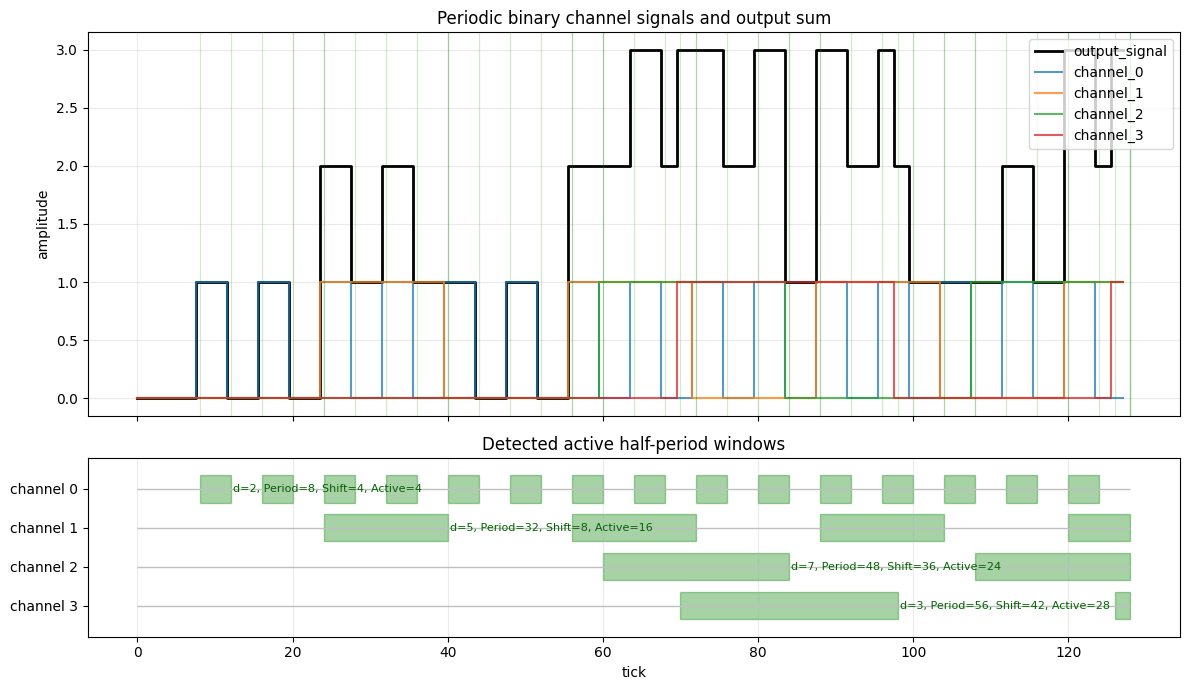

In [7]:
import matplotlib.patches as patches
plot_ticks=ticks
ticks_axis=[s.tick for s in encoded_signal[:plot_ticks]]
series=[[s.channel_amplitudes[ch] for s in encoded_signal[:plot_ticks]] for ch in range(digit_count)]
output=[s.total_amplitude for s in encoded_signal[:plot_ticks]]
colors=["tab:blue","tab:orange","tab:green","tab:red"]
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(12,7),sharex=True,gridspec_kw={"height_ratios":[3,1.4]})
ax1.step(ticks_axis, output, where="mid", color="black", linewidth=2, label="output_signal")
for ch,vals in enumerate(series): ax1.step(ticks_axis, vals, where="mid", color=colors[ch], alpha=.75, label=f"channel_{ch}")
for ch, vals in enumerate(series):
    y=digit_count-1-ch; cell=source_cells[ch]
    ax2.hlines(y,0,plot_ticks,color="0.75",linewidth=1)
    for start,end in nonzero_windows(vals):
        ax2.add_patch(patches.Rectangle((start,y-.35),end-start,.7,facecolor="green",edgecolor="green",alpha=.35))
        ax1.axvline(start,color="green",alpha=.18,linewidth=.9); ax1.axvline(end,color="green",alpha=.18,linewidth=.9)
    wins=nonzero_windows(vals)
    if wins: ax2.text(wins[0][1]+.3,y,f"d={cell.digit_value}, Period={cell.period_ticks}, Shift={cell.shift_ticks}, Active={cell.active_width_ticks}",va="center",fontsize=8,color="darkgreen")
ax1.set_ylabel("amplitude"); ax1.set_title("Periodic binary channel signals and output sum"); ax1.grid(True,alpha=.25); ax1.legend(loc="upper right")
ax2.set_yticks(list(range(digit_count))); ax2.set_yticklabels([f"channel {digit_count-1-i}" for i in range(digit_count)]); ax2.set_ylim(-.8,digit_count-.2); ax2.set_xlabel("tick"); ax2.set_title("Detected active half-period windows"); ax2.grid(True,axis="x",alpha=.25)
plt.tight_layout(); plt.show()

## 7. Tick-Level Decode Table

RU: `active` показывает активные каналы в такте. `output` может быть больше `1`, если активны несколько бинарных каналов.

EN: `active` lists active channels at a tick. `output` can be greater than `1` if several binary channels are active.

In [8]:
print_table([{ "tick": s.tick, "active": [i for i,v in enumerate(s.channel_amplitudes) if v>0], "output": s.total_amplitude, "ch_0": s.channel_amplitudes[0], "ch_1": s.channel_amplitudes[1], "ch_2": s.channel_amplitudes[2], "ch_3": s.channel_amplitudes[3] } for s in encoded_signal[:24]])

tick | active | output | ch_0 | ch_1 | ch_2 | ch_3
-----+--------+--------+------+------+------+-----
0    | []     | 0.0    | 0.0  | 0.0  | 0.0  | 0.0 
1    | []     | 0.0    | 0.0  | 0.0  | 0.0  | 0.0 
2    | []     | 0.0    | 0.0  | 0.0  | 0.0  | 0.0 
3    | []     | 0.0    | 0.0  | 0.0  | 0.0  | 0.0 
4    | []     | 0.0    | 0.0  | 0.0  | 0.0  | 0.0 
5    | []     | 0.0    | 0.0  | 0.0  | 0.0  | 0.0 
6    | []     | 0.0    | 0.0  | 0.0  | 0.0  | 0.0 
7    | []     | 0.0    | 0.0  | 0.0  | 0.0  | 0.0 
8    | [0]    | 1.0    | 1.0  | 0.0  | 0.0  | 0.0 
9    | [0]    | 1.0    | 1.0  | 0.0  | 0.0  | 0.0 
10   | [0]    | 1.0    | 1.0  | 0.0  | 0.0  | 0.0 
11   | [0]    | 1.0    | 1.0  | 0.0  | 0.0  | 0.0 
12   | []     | 0.0    | 0.0  | 0.0  | 0.0  | 0.0 
13   | []     | 0.0    | 0.0  | 0.0  | 0.0  | 0.0 
14   | []     | 0.0    | 0.0  | 0.0  | 0.0  | 0.0 
15   | []     | 0.0    | 0.0  | 0.0  | 0.0  | 0.0 
16   | [0]    | 1.0    | 1.0  | 0.0  | 0.0  | 0.0 
17   | [0]    | 1.0    | 1.0  |

## 8. Decoded Channel Parameters / Восстановленные параметры каналов

RU: основной декодер теперь работает по одному `output_signal`: он измеряет первый активный сегмент остатка, получает `Period` и `Shift`, вычитает восстановленный канал и переходит к следующему, более низкочастотному каналу.

EN: the primary decoder now works on a single `output_signal`: it measures the first active segment in the residual, recovers `Period` and `Shift`, subtracts the restored channel, and moves to the next lower-frequency channel.

In [9]:
candidate_rows=[]; decoded_rows=[]
channel_signals = [
    [s.channel_amplitudes[ch] for s in encoded_signal]
    for ch in range(digit_count)
]
summed_signal = [s.total_amplitude for s in encoded_signal]
for ch, channel_signal in enumerate(channel_signals):
    best=None
    for cand in matrix_number.candidate_cells(ch):
        hits,errors=score_candidate(matrix_number, channel_signal, cand)
        row={"channel":ch,"digit":cand.digit_value,"Period":cand.period_ticks,"Shift":cand.shift_ticks,"Active":cand.active_width_ticks,"hits":hits,"errors":errors,"first_windows":matrix_number.cell_active_windows(cand,ticks=ticks)[:3]}
        candidate_rows.append(row)
        if best is None or (row["errors"],-row["hits"]) < (best["errors"],-best["hits"]): best=row
    decoded_rows.append({k:best[k] for k in ["channel","digit","Period","Shift","Active","hits","errors"]})
separated_result = matrix_number.decode_channel_signals(channel_signals)
summed_result = matrix_number.decode_step_signal(summed_signal, digit_count=digit_count)
print("Candidate examples for separated channels / Примеры для разделённых каналов")
print_table(candidate_rows, max_width=42)
print("\nSelected cells / Выбранные ячейки")
print_table(decoded_rows)
print("\nSummed output peeling decoder / Peeling-декодер по суммарному сигналу")
print({"digits": list(summed_result.digits), "number": summed_result.number, "method": summed_result.method})
print("\nSeparated-channel API check / Проверка по разделённым каналам")
print({"digits": list(separated_result.digits), "number": separated_result.number, "method": separated_result.method})

Candidate examples for separated channels / Примеры для разделённых каналов

channel | digit | Period | Shift | Active | hits | errors | first_windows                    
--------+-------+--------+-------+--------+------+--------+----------------------------------
0       | 0     | 8      | 0     | 4      | 0    | 124    | [(4, 8), (12, 16), (20, 24)]     
0       | 1     | 8      | 2     | 4      | 30   | 62     | [(6, 10), (14, 18), (22, 26)]    
0       | 2     | 8      | 4     | 4      | 60   | 0      | [(8, 12), (16, 20), (24, 28)]    
0       | 3     | 8      | 6     | 4      | 30   | 60     | [(10, 14), (18, 22), (26, 30)]   
0       | 4     | 16     | 0     | 8      | 32   | 60     | [(8, 16), (24, 32), (40, 48)]    
0       | 5     | 16     | 4     | 8      | 28   | 64     | [(12, 20), (28, 36), (44, 52)]   
0       | 6     | 16     | 8     | 8      | 28   | 60     | [(16, 24), (32, 40), (48, 56)]   
0       | 7     | 16     | 12    | 8      | 28   | 60     | [(20, 28), (36, 44), (52, 60)]   
1       | 0     | 24     | 0     | 12     | 24   | 68     | 

## 9. Matrix Digits -> Decimal Number

RU: восстановленные цифры переводятся обратно в десятичное число.

EN: recovered digits are converted back to the decimal number.

In [10]:
decoded_digits=list(summed_result.digits)
decoded_number=summed_result.number
terms=[f"{d} * {matrix_number.base}^{i}" for i,d in enumerate(decoded_digits)]
print({"decoded_digits_little_endian_lsf_high_freq_to_msf_low_freq": decoded_digits, "decimal_formula": " + ".join(terms), "decoded_number": decoded_number, "separated_check_number": separated_result.number, "method": summed_result.method})

{'decoded_digits_little_endian_lsf_high_freq_to_msf_low_freq': [2, 5, 7, 3], 'decimal_formula': '2 * 8^0 + 5 * 8^1 + 7 * 8^2 + 3 * 8^3', 'decoded_number': 2026, 'separated_check_number': 2026, 'method': 'summed signal peeling decoder'}
